# 2.3 Visualisation des Espaces d'Embeddings

Projection t-SNE/UMAP des produits en 2D pour les 4 méthodes d'embeddings :
- **Méthode 1** : TF-IDF (texte)
- **Méthode 2** : Embeddings neuronaux (texte)
- **Méthode 3** : ResNet-50 (image)
- **Méthode 4** : ViT (image)

**Objectifs** :
- Colorier par catégorie
- Annoter les cas tests (visuellement similaires / sémantiquement similaires)

## Imports et Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

In [2]:
# Charger le dataset
df = pd.read_csv('data/subset_fashion_dataset/products_final.csv')
print(f"Dataset : {len(df)} produits")
print(f"Catégories : {df['categorie'].nunique()}")
print(f"\nDistribution :\n{df['categorie'].value_counts()}")

Dataset : 400 produits
Catégories : 8

Distribution :
categorie
Topwear       50
Shoes         50
Bags          50
Bottomwear    50
Watches       50
Innerwear     50
Jewellery     50
Eyewear       50
Name: count, dtype: int64


In [3]:
# Charger les embeddings
tfidf_matrix = np.load('results/tfidf_similarity_matrix.npy')
text_embeddings = np.load('results/text_embeddings.npy')
resnet_embeddings = np.load('results/resnet_embeddings.npy')
vit_embeddings = np.load('results/vit_embeddings.npy')

print("Embeddings chargés :")
print(f"  - TF-IDF      : {tfidf_matrix.shape}")
print(f"  - Text emb    : {text_embeddings.shape}")
print(f"  - ResNet      : {resnet_embeddings.shape}")
print(f"  - ViT         : {vit_embeddings.shape}")

Embeddings chargés :
  - TF-IDF      : (400, 400)
  - Text emb    : (400, 384)
  - ResNet      : (400, 2048)
  - ViT         : (400, 768)


In [4]:
# Charger les résultats top-5 pour identifier les cas tests
df_tfidf = pd.read_csv('results/tfidf_top5_anchors.csv')
df_resnet = pd.read_csv('results/resnet_top5_anchors.csv')
df_vit = pd.read_csv('results/vit_top5_anchors.csv')

print("Résultats top-5 chargés")

Résultats top-5 chargés


In [5]:
# Configuration des couleurs par catégorie
categories = df['categorie'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(categories)))
category_colors = dict(zip(categories, colors))

df['color'] = df['categorie'].map(category_colors)

print(f"Couleurs définies pour {len(categories)} catégories")

Couleurs définies pour 8 catégories


---
## Méthode 1 : TF-IDF (Texte)

In [6]:
# Application t-SNE
print("Projection t-SNE en cours (TF-IDF)...")
tsne_tfidf = TSNE(n_components=2, random_state=42, perplexity=30)
tfidf_2d = tsne_tfidf.fit_transform(tfidf_matrix)
print(f"Projection : {tfidf_2d.shape}")

Projection t-SNE en cours (TF-IDF)...
Projection : (400, 2)


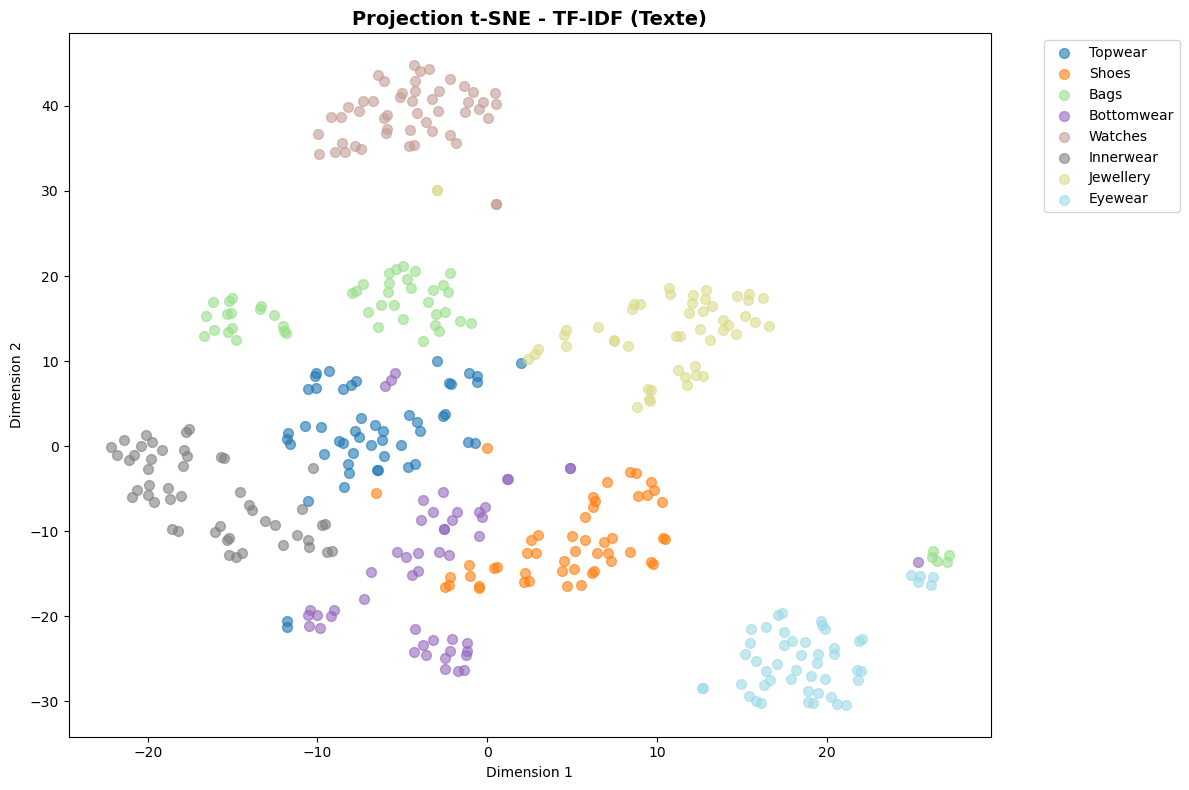

Visualisation sauvegardée : results/tsne_tfidf.png


In [7]:
# Visualisation
plt.figure(figsize=(12, 8))

# Scatter plot coloré par catégorie
for category in categories:
    mask = df['categorie'] == category
    plt.scatter(tfidf_2d[mask, 0], tfidf_2d[mask, 1], 
               c=[category_colors[category]], label=category, alpha=0.6, s=50)

plt.title('Projection t-SNE - TF-IDF (Texte)', fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('results/tsne_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualisation sauvegardée : results/tsne_tfidf.png")

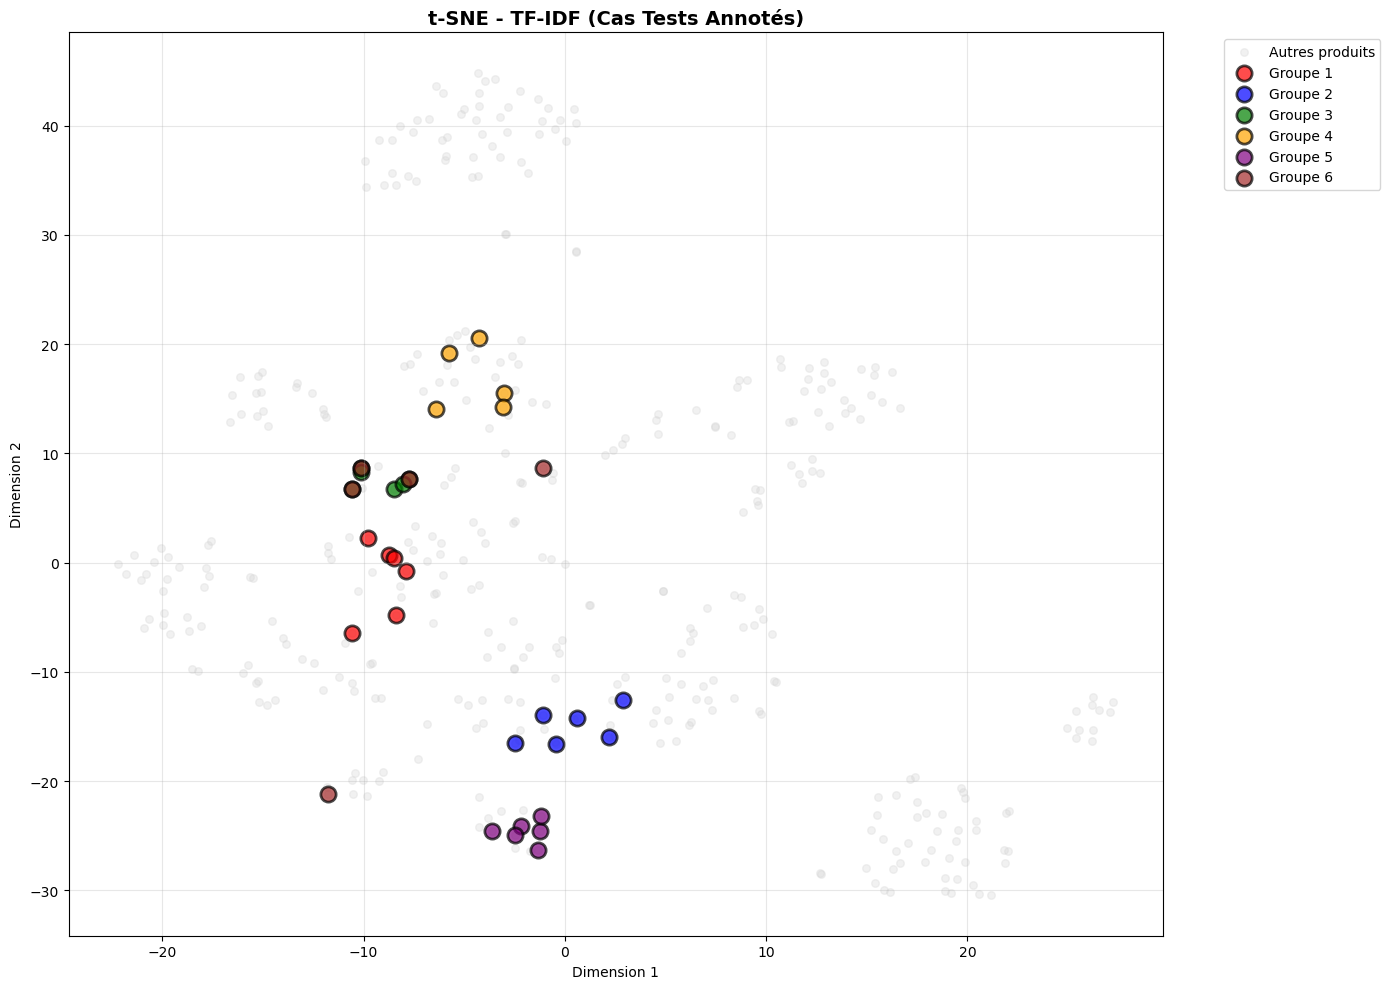

Annotation TF-IDF sauvegardée


In [8]:
# ===== ANNOTATION CAS TESTS - MÉTHODE 1 : TF-IDF =====

# Charger les cas tests
cas_tests = pd.read_csv('results/cas_tests_identifies.csv')

# Préparer les données d'annotation
groupes_tfidf = {}
for idx, row in cas_tests.iterrows():
    gid = row['Groupe']
    ancre_id = row['Ancre_ID']
    associes_str = row['Produits_Associes']
    associes = [int(x.strip()) for x in associes_str.split(',')] if isinstance(associes_str, str) else []
    tous_les_produits = [ancre_id] + associes
    
    indices = []
    for pid in tous_les_produits:
        produit_df = df[df['id'] == pid]
        if len(produit_df) > 0:
            indices.append(produit_df.index[0])
    
    groupes_tfidf[gid] = indices

# Visualisation TF-IDF avec annotations
plt.figure(figsize=(14, 10))

# Background
plt.scatter(tfidf_2d[:, 0], tfidf_2d[:, 1], c='lightgray', alpha=0.3, s=30, label='Autres produits')

# Annoter chaque groupe avec une couleur différente
couleurs_groupe = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
for gid, indices in groupes_tfidf.items():
    if len(indices) > 0:
        plt.scatter(tfidf_2d[indices, 0], tfidf_2d[indices, 1], 
                   c=couleurs_groupe[gid-1], alpha=0.7, s=120, 
                   marker='o', edgecolors='black', linewidths=2,
                   label=f'Groupe {gid}')

plt.title('t-SNE - TF-IDF (Cas Tests Annotés)', fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/tsne_tfidf_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

print("Annotation TF-IDF sauvegardée")


---
## Méthode 2 : Embeddings Neuronaux (Texte)

In [9]:
# Application t-SNE
print("Projection t-SNE en cours (Embeddings neuronaux)...")
tsne_emb = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne_emb.fit_transform(text_embeddings)
print(f"Projection : {emb_2d.shape}")

Projection t-SNE en cours (Embeddings neuronaux)...
Projection : (400, 2)


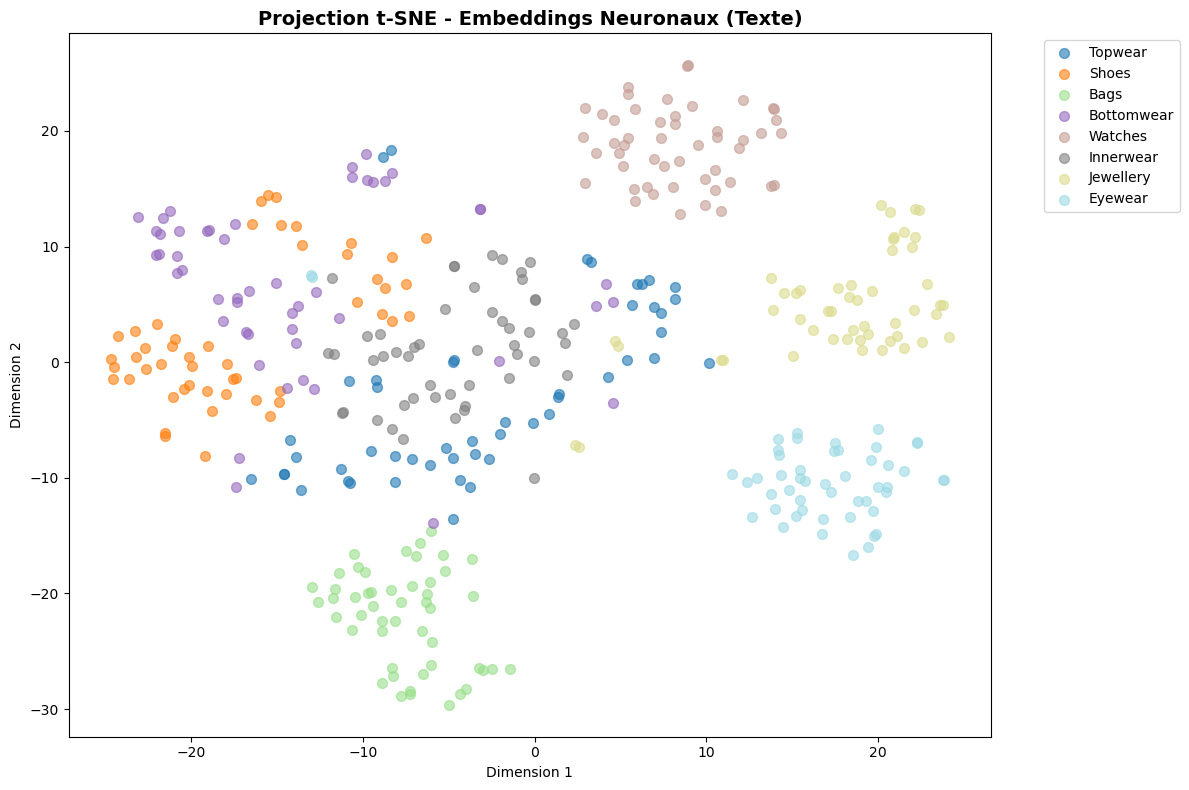

Visualisation sauvegardée : results/tsne_embeddings.png


In [10]:
# Visualisation
plt.figure(figsize=(12, 8))

for category in categories:
    mask = df['categorie'] == category
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], 
               c=[category_colors[category]], label=category, alpha=0.6, s=50)

plt.title('Projection t-SNE - Embeddings Neuronaux (Texte)', fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('results/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualisation sauvegardée : results/tsne_embeddings.png")

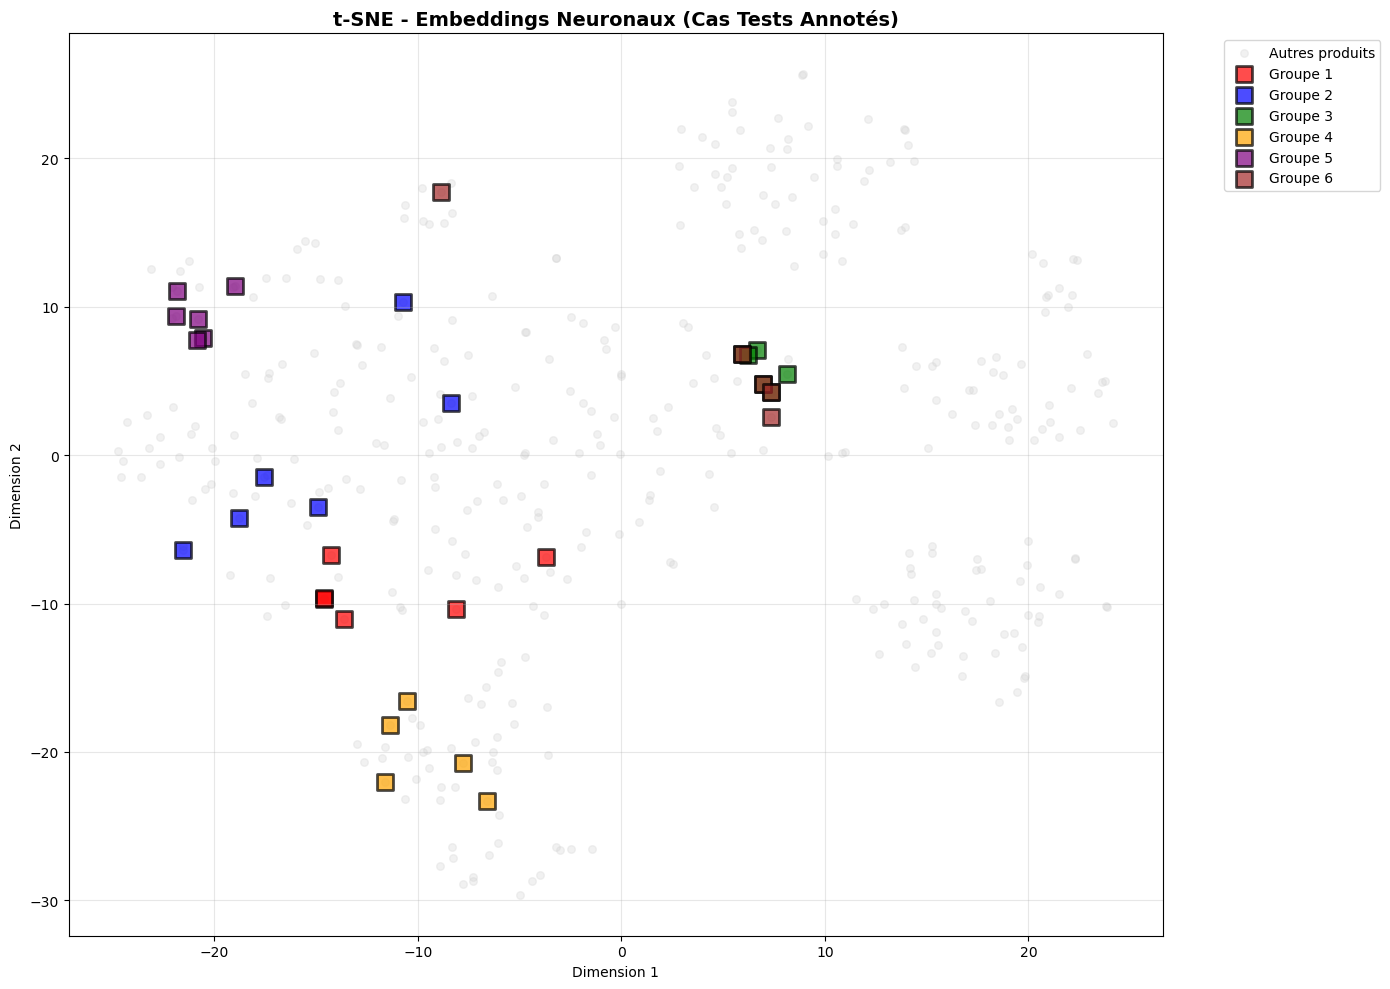

Annotation Embeddings sauvegardée


In [11]:
# ===== ANNOTATION CAS TESTS - MÉTHODE 2 : EMBEDDINGS =====

plt.figure(figsize=(14, 10))

# Background
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c='lightgray', alpha=0.3, s=30, label='Autres produits')

# Annoter chaque groupe
for gid, indices in groupes_tfidf.items():
    if len(indices) > 0:
        plt.scatter(emb_2d[indices, 0], emb_2d[indices, 1], 
                   c=couleurs_groupe[gid-1], alpha=0.7, s=120, 
                   marker='s', edgecolors='black', linewidths=2,
                   label=f'Groupe {gid}')

plt.title('t-SNE - Embeddings Neuronaux (Cas Tests Annotés)', fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/tsne_embeddings_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

print("Annotation Embeddings sauvegardée")


---
## Méthode 3 : ResNet-50 (Image)

In [12]:
# Application t-SNE
print("Projection t-SNE en cours (ResNet-50)...")
tsne_resnet = TSNE(n_components=2, random_state=42, perplexity=30)
resnet_2d = tsne_resnet.fit_transform(resnet_embeddings)
print(f"Projection : {resnet_2d.shape}")

Projection t-SNE en cours (ResNet-50)...
Projection : (400, 2)


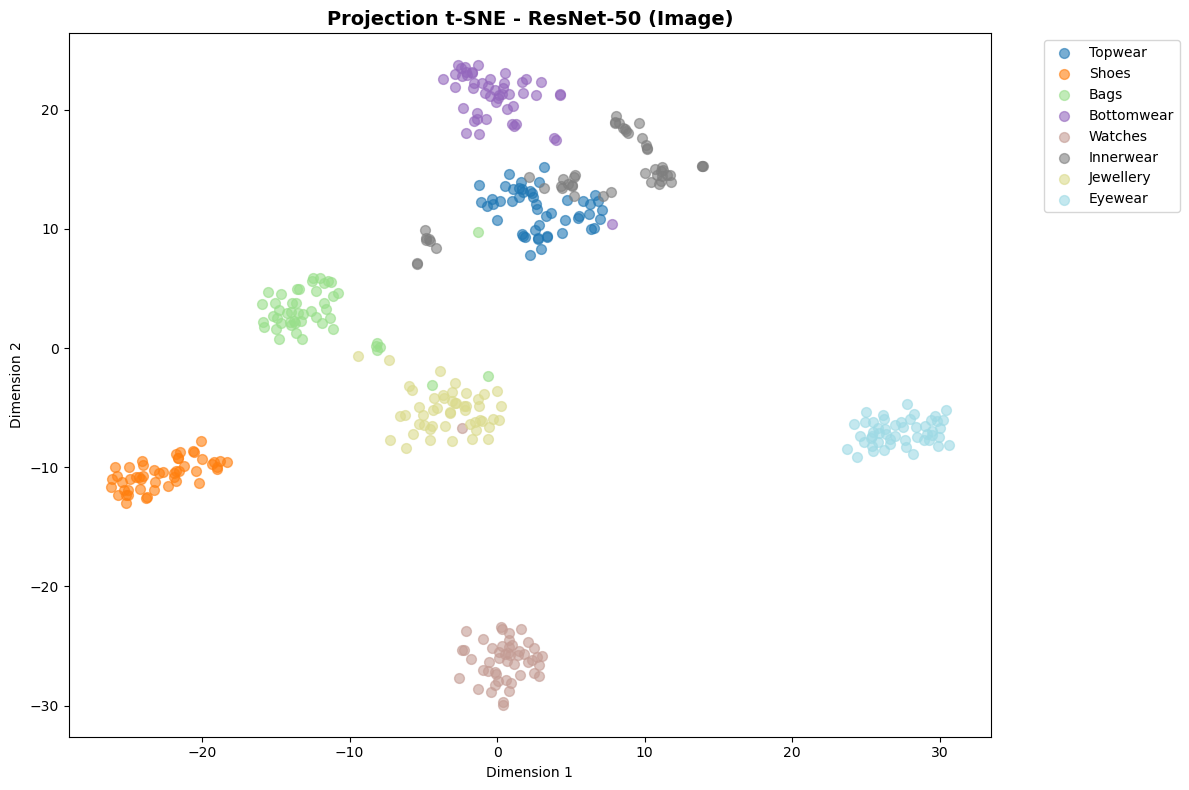

Visualisation sauvegardée : results/tsne_resnet.png


In [13]:
# Visualisation
plt.figure(figsize=(12, 8))

for category in categories:
    mask = df['categorie'] == category
    plt.scatter(resnet_2d[mask, 0], resnet_2d[mask, 1], 
               c=[category_colors[category]], label=category, alpha=0.6, s=50)

plt.title('Projection t-SNE - ResNet-50 (Image)', fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('results/tsne_resnet.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualisation sauvegardée : results/tsne_resnet.png")

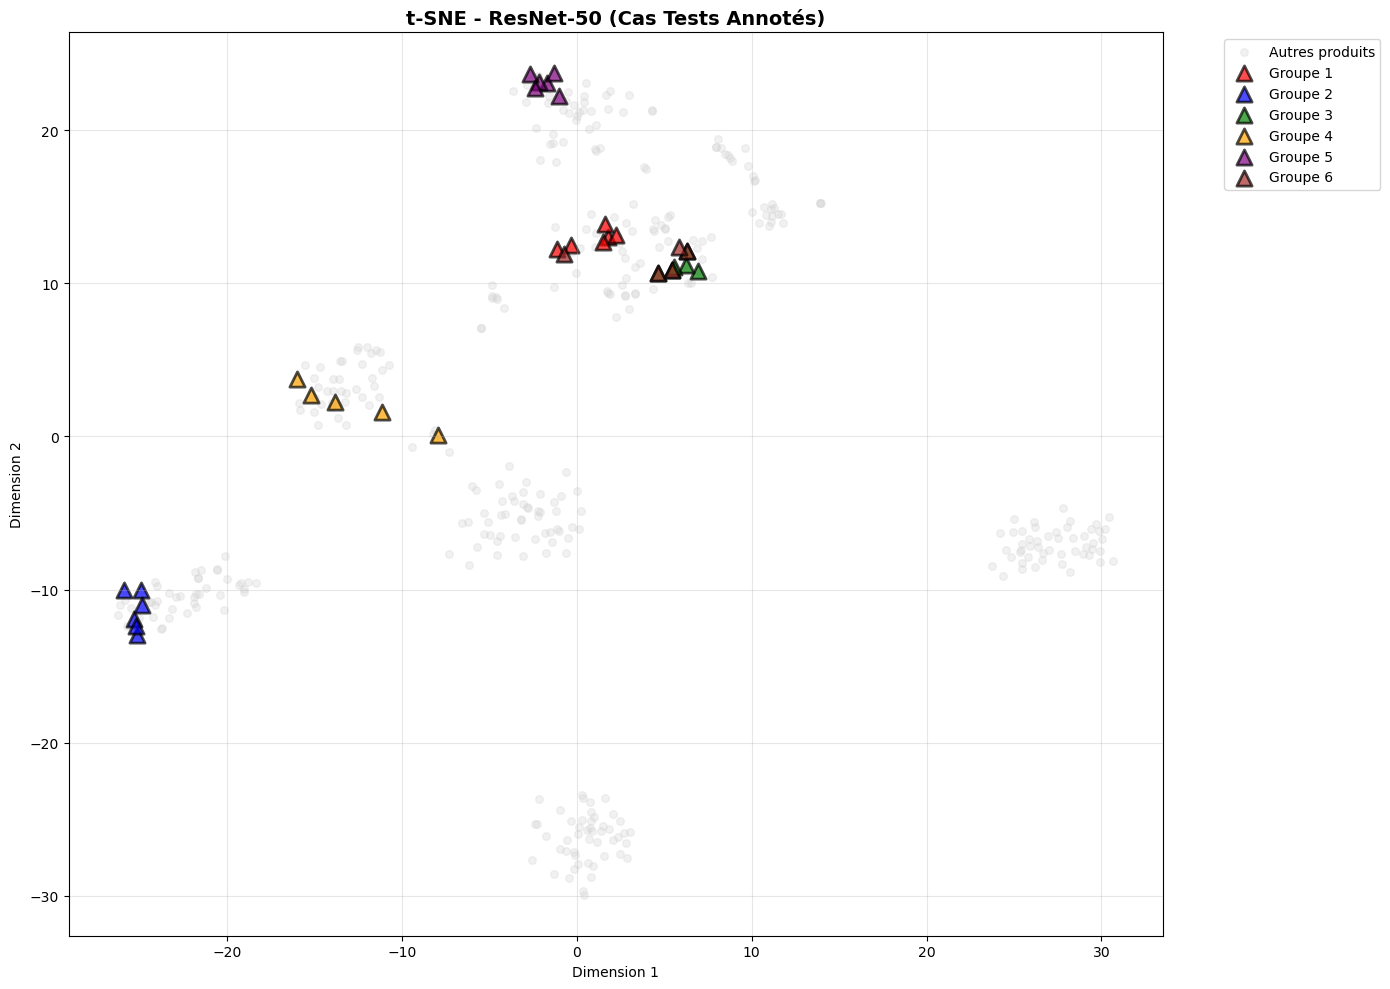

Annotation ResNet-50 sauvegardée


In [14]:
# ===== ANNOTATION CAS TESTS - MÉTHODE 3 : RESNET-50 =====

plt.figure(figsize=(14, 10))

# Background
plt.scatter(resnet_2d[:, 0], resnet_2d[:, 1], c='lightgray', alpha=0.3, s=30, label='Autres produits')

# Annoter chaque groupe
for gid, indices in groupes_tfidf.items():
    if len(indices) > 0:
        plt.scatter(resnet_2d[indices, 0], resnet_2d[indices, 1], 
                   c=couleurs_groupe[gid-1], alpha=0.7, s=120, 
                   marker='^', edgecolors='black', linewidths=2,
                   label=f'Groupe {gid}')

plt.title('t-SNE - ResNet-50 (Cas Tests Annotés)', fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/tsne_resnet_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

print("Annotation ResNet-50 sauvegardée")


---
## Méthode 4 : ViT (Image)

In [15]:
# Application t-SNE
print("Projection t-SNE en cours (ViT)...")
tsne_vit = TSNE(n_components=2, random_state=42, perplexity=30)
vit_2d = tsne_vit.fit_transform(vit_embeddings)
print(f"Projection : {vit_2d.shape}")

Projection t-SNE en cours (ViT)...
Projection : (400, 2)


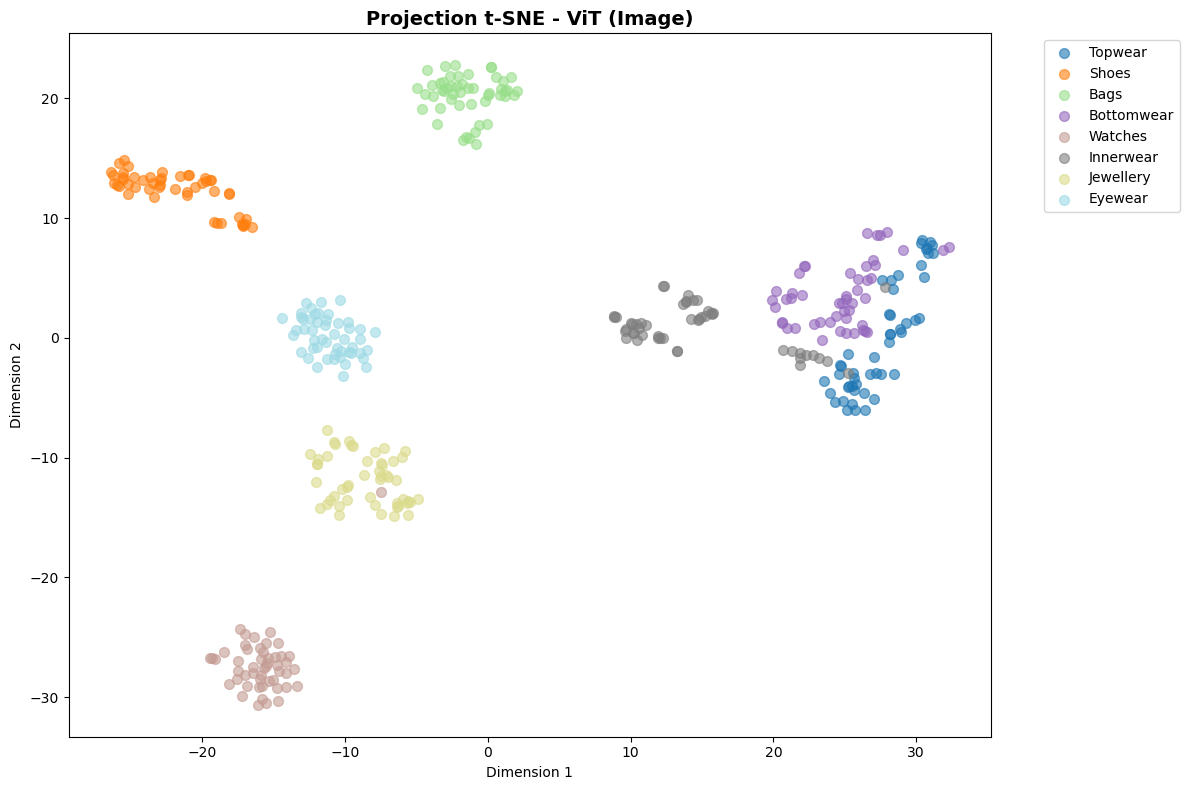

Visualisation sauvegardée : results/tsne_vit.png


In [16]:
# Visualisation
plt.figure(figsize=(12, 8))

for category in categories:
    mask = df['categorie'] == category
    plt.scatter(vit_2d[mask, 0], vit_2d[mask, 1], 
               c=[category_colors[category]], label=category, alpha=0.6, s=50)

plt.title('Projection t-SNE - ViT (Image)', fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('results/tsne_vit.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualisation sauvegardée : results/tsne_vit.png")

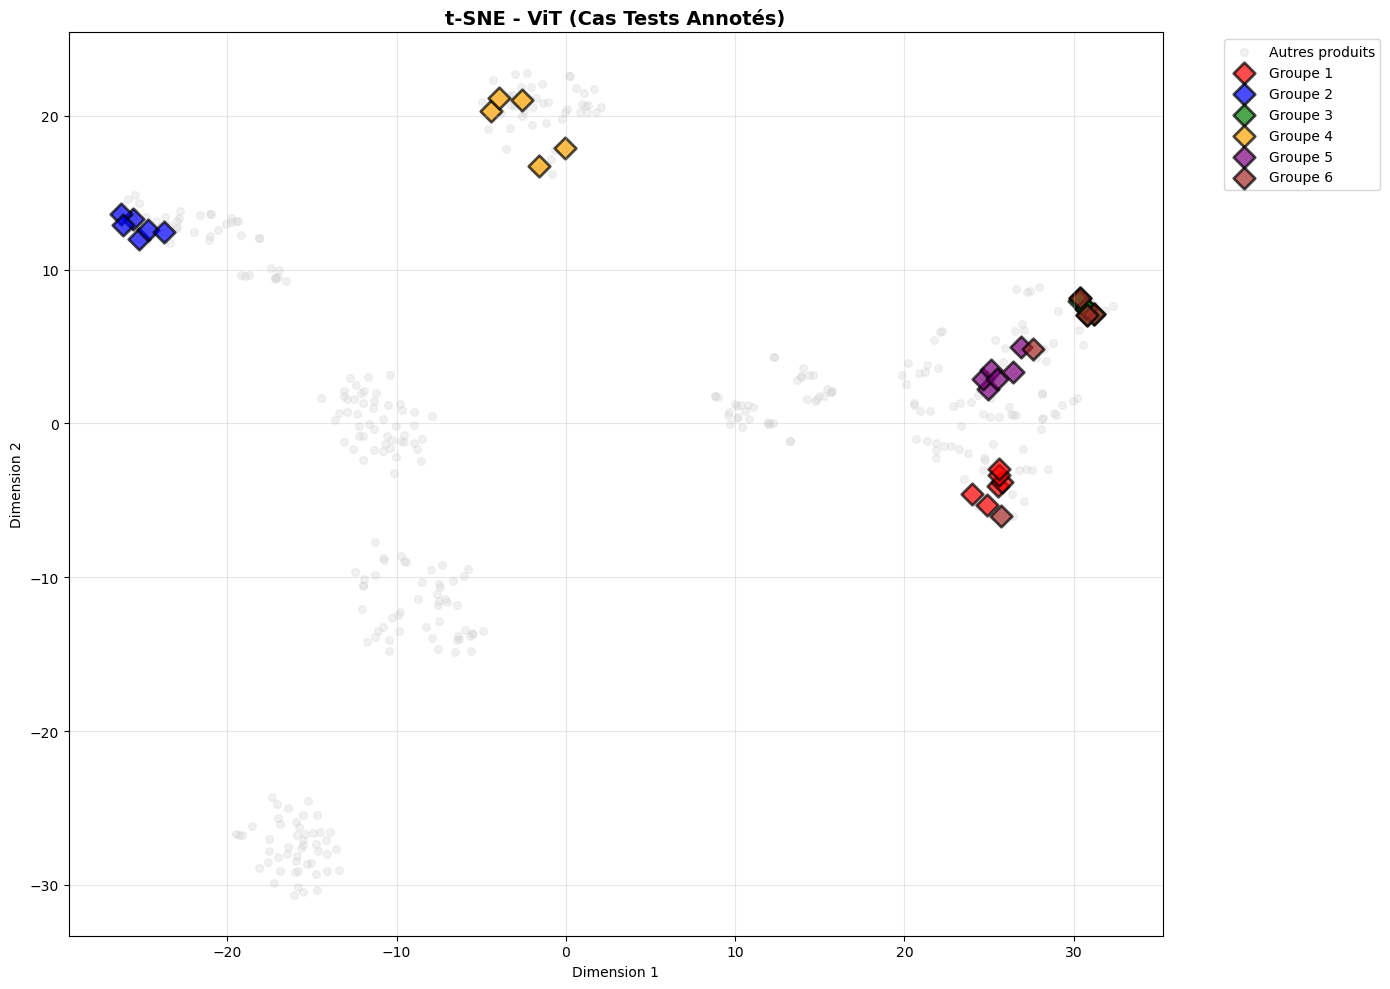

Annotation ViT sauvegardée


In [17]:
# ===== ANNOTATION CAS TESTS - MÉTHODE 4 : VIT =====

plt.figure(figsize=(14, 10))

# Background
plt.scatter(vit_2d[:, 0], vit_2d[:, 1], c='lightgray', alpha=0.3, s=30, label='Autres produits')

# Annoter chaque groupe
for gid, indices in groupes_tfidf.items():
    if len(indices) > 0:
        plt.scatter(vit_2d[indices, 0], vit_2d[indices, 1], 
                   c=couleurs_groupe[gid-1], alpha=0.7, s=120, 
                   marker='D', edgecolors='black', linewidths=2,
                   label=f'Groupe {gid}')

plt.title('t-SNE - ViT (Cas Tests Annotés)', fontsize=14, fontweight='bold')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/tsne_vit_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

print("Annotation ViT sauvegardée")


---
## Annotation des Cas Tests

In [18]:
# Charger le ground truth et extraire les cas tests
ground_truth = pd.read_csv('data/subset_fashion_dataset/ground_truth.csv', sep=';')
print(f"Ground truth chargé : {len(ground_truth)} ancres")

# Créer les ensembles de produits pour chaque type
visual_products = set()
semantic_products = set()
anchor_to_index = {}

for idx, row in df.iterrows():
    anchor_to_index[row['id']] = idx

for _, row in ground_truth.iterrows():
    anchor_id = row['anchor_id']
    
    # Extraire visual_id
    for i in range(1, 6):
        visual_id = row[f'visual_id{i}']
        if pd.notna(visual_id):
            visual_products.add(int(visual_id))
    
    # Extraire semantic_id
    for i in range(1, 6):
        semantic_id = row[f'semantic_id{i}']
        if pd.notna(semantic_id):
            semantic_products.add(int(semantic_id))

# Calculer les intersections
visual_only = visual_products - semantic_products
semantic_only = semantic_products - visual_products
both = visual_products & semantic_products

print(f"\nRépartition des cas tests :")
print(f"  - Visuels uniquement     : {len(visual_only)}")
print(f"  - Sémantiques uniquement : {len(semantic_only)}")
print(f"  - Les deux               : {len(both)}")

Ground truth chargé : 30 ancres

Répartition des cas tests :
  - Visuels uniquement     : 73
  - Sémantiques uniquement : 61
  - Les deux               : 67


Zoom sur le Groupe 2 : Nike Womens Air Rele Purple Shoe
Type : Visuellement_similaires_sémantiquement_différents


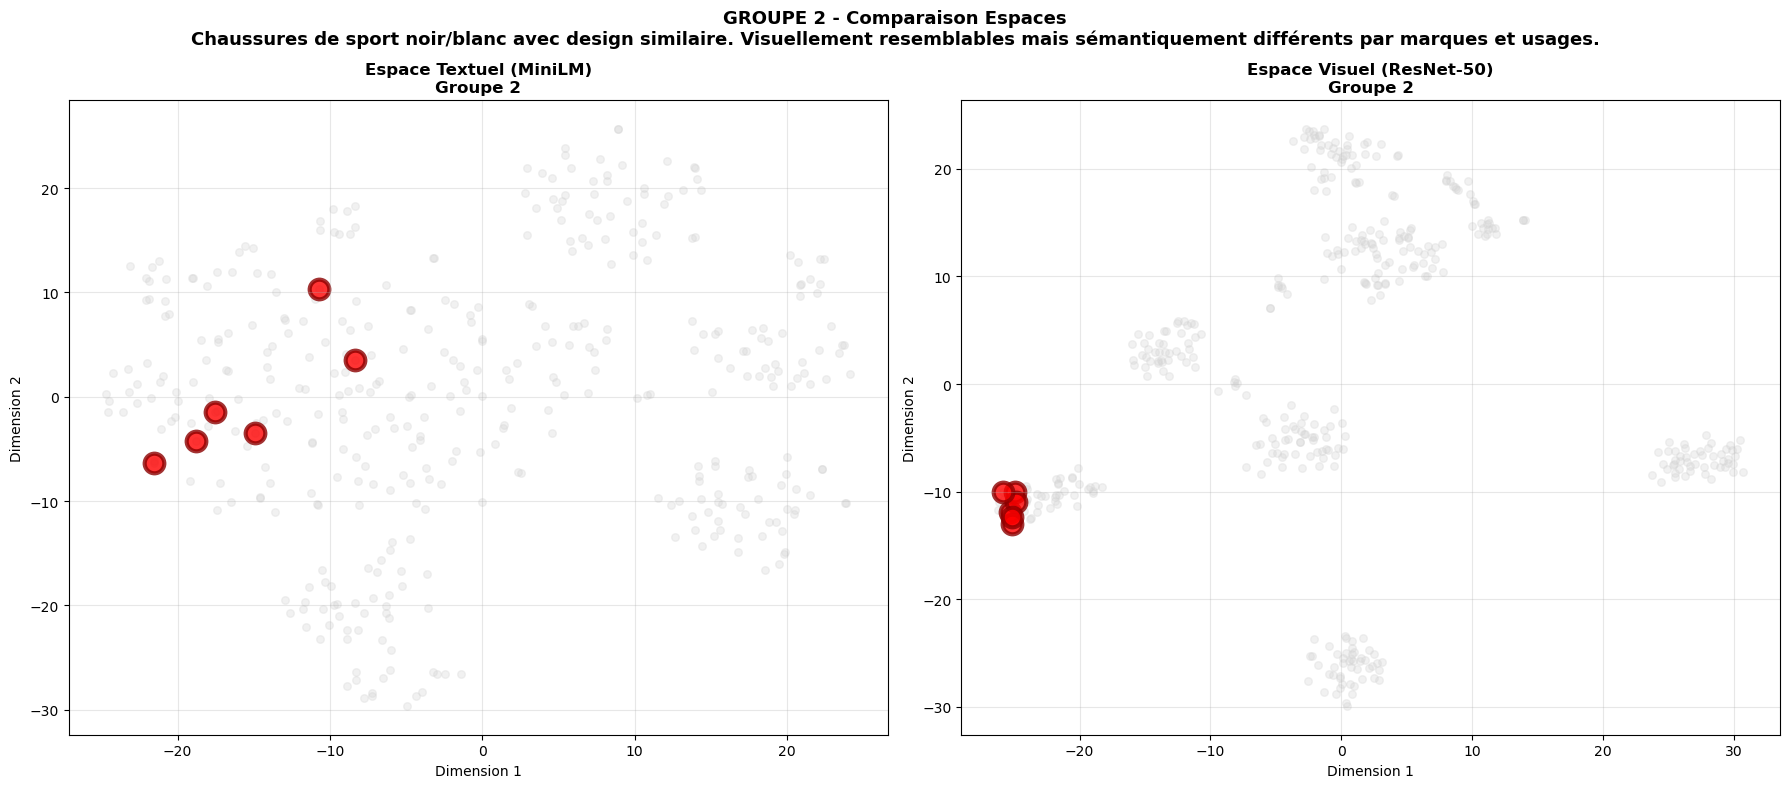

In [19]:
# ===== ZOOM SUR UN GROUPE SPÉCIFIQUE =====

# Choix du groupe à zoomer (exemple: Groupe 2 - Chaussures)
groupe_id = 2
groupe_indices = groupes_tfidf[groupe_id]
groupe_info = cas_tests[cas_tests['Groupe'] == groupe_id].iloc[0]

print(f"Zoom sur le Groupe {groupe_id} : {groupe_info['Ancre_Nom']}")
print(f"Type : {groupe_info['Type']}")

# Comparaison Texte vs Visuel pour ce groupe
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Espace Textuel
axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c='lightgray', alpha=0.3, s=30)
if len(groupe_indices) > 0:
    axes[0].scatter(emb_2d[groupe_indices, 0], emb_2d[groupe_indices, 1], 
                   c='red', alpha=0.8, s=200, marker='o', edgecolors='darkred', linewidths=3)

axes[0].set_title(f'Espace Textuel (MiniLM)\nGroupe {groupe_id}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].grid(True, alpha=0.3)

# Espace Visuel
axes[1].scatter(resnet_2d[:, 0], resnet_2d[:, 1], c='lightgray', alpha=0.3, s=30)
if len(groupe_indices) > 0:
    axes[1].scatter(resnet_2d[groupe_indices, 0], resnet_2d[groupe_indices, 1], 
                   c='red', alpha=0.8, s=200, marker='o', edgecolors='darkred', linewidths=3)

axes[1].set_title(f'Espace Visuel (ResNet-50)\nGroupe {groupe_id}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'GROUPE {groupe_id} - Comparaison Espaces\n{groupe_info["Explication"]}', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'results/zoom_groupe{groupe_id}_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()


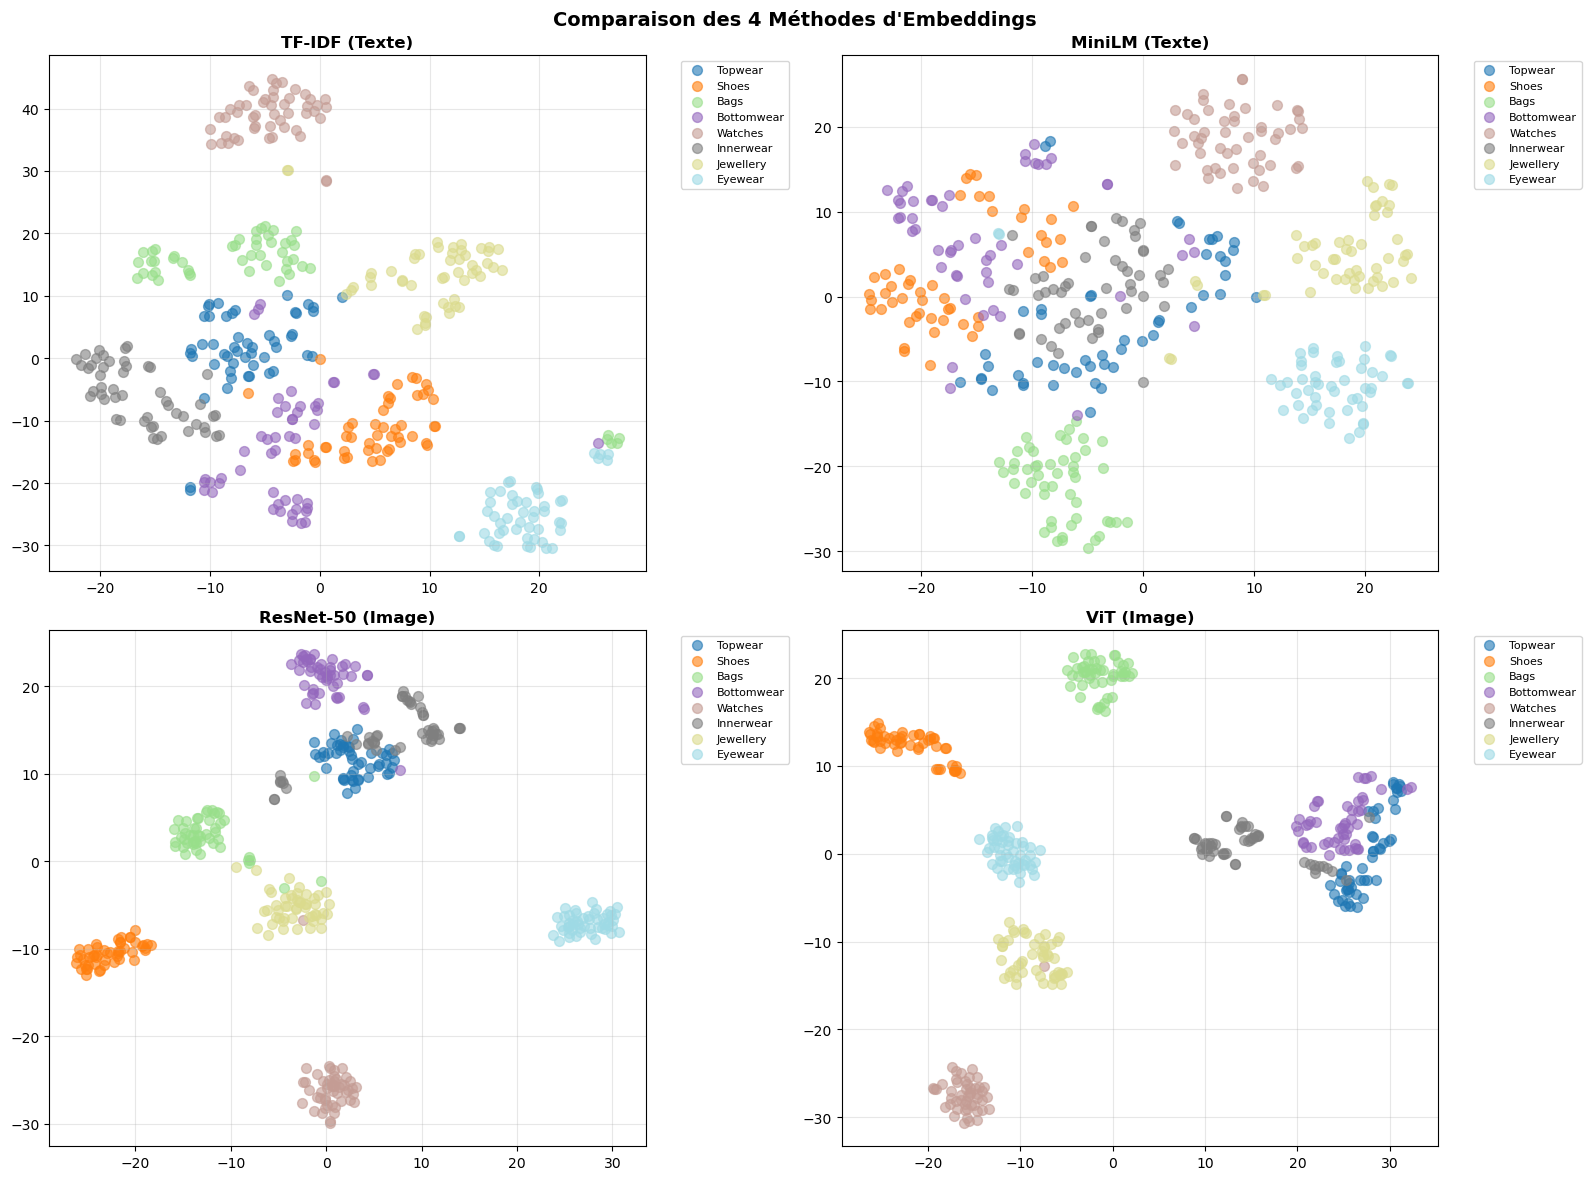

✅ Figure 1 sauvegardée : tsne_4methods_sans_annotation.png


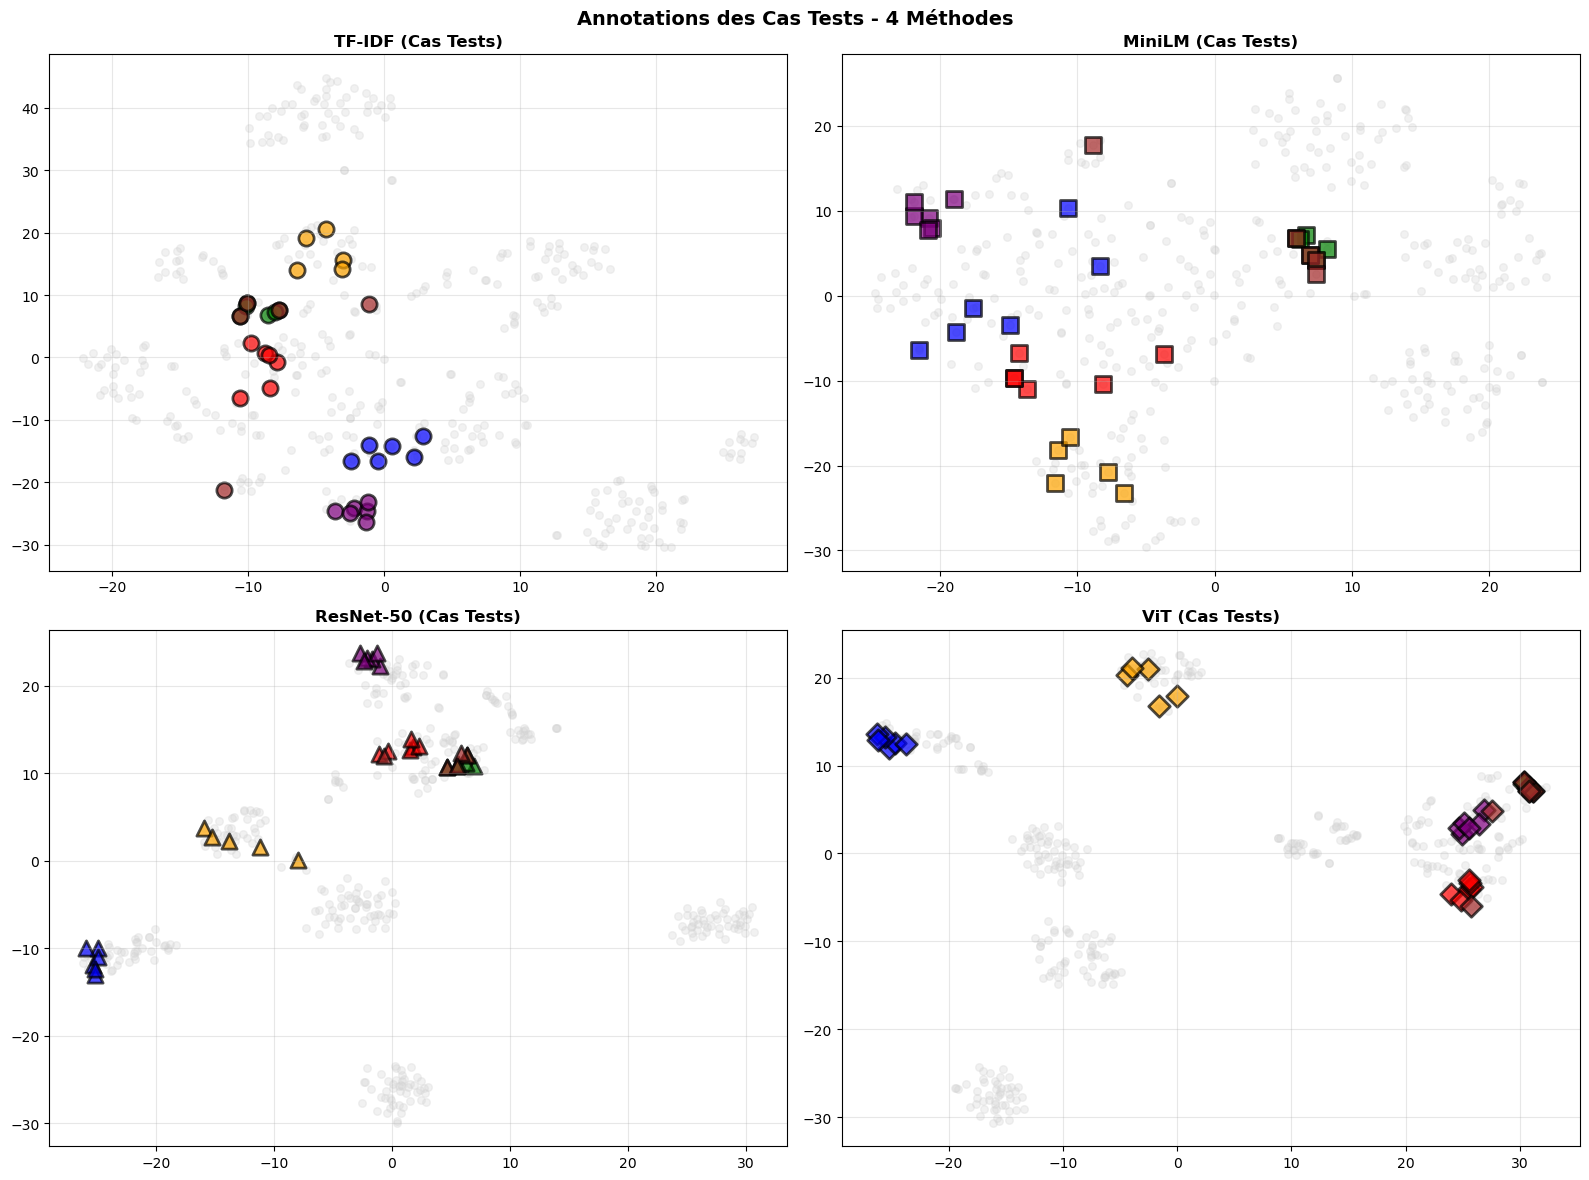

✅ Figure 2 sauvegardée : tsne_4methods_avec_annotation.png


In [20]:
# ===== FIGURE 1 : 4 MÉTHODES SANS ANNOTATION =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# TF-IDF
for category in categories:
    mask = df['categorie'] == category
    axes[0, 0].scatter(tfidf_2d[mask, 0], tfidf_2d[mask, 1], 
                   c=[category_colors[category]], label=category, alpha=0.6, s=50)
axes[0, 0].set_title('TF-IDF (Texte)', fontsize=12, fontweight='bold')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Embeddings
for category in categories:
    mask = df['categorie'] == category
    axes[0, 1].scatter(emb_2d[mask, 0], emb_2d[mask, 1], 
                   c=[category_colors[category]], label=category, alpha=0.6, s=50)
axes[0, 1].set_title('MiniLM (Texte)', fontsize=12, fontweight='bold')
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# ResNet-50
for category in categories:
    mask = df['categorie'] == category
    axes[1, 0].scatter(resnet_2d[mask, 0], resnet_2d[mask, 1], 
                   c=[category_colors[category]], label=category, alpha=0.6, s=50)
axes[1, 0].set_title('ResNet-50 (Image)', fontsize=12, fontweight='bold')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# ViT
for category in categories:
    mask = df['categorie'] == category
    axes[1, 1].scatter(vit_2d[mask, 0], vit_2d[mask, 1], 
                   c=[category_colors[category]], label=category, alpha=0.6, s=50)
axes[1, 1].set_title('ViT (Image)', fontsize=12, fontweight='bold')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('Comparaison des 4 Méthodes d\'Embeddings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/tsne_4methods_sans_annotation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Figure 1 sauvegardée : tsne_4methods_sans_annotation.png")


# ===== FIGURE 2 : 4 MÉTHODES AVEC ANNOTATION =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# TF-IDF annoté
axes[0, 0].scatter(tfidf_2d[:, 0], tfidf_2d[:, 1], c='lightgray', alpha=0.3, s=30)
for gid, indices in groupes_tfidf.items():
    if len(indices) > 0:
        axes[0, 0].scatter(tfidf_2d[indices, 0], tfidf_2d[indices, 1], 
                       c=couleurs_groupe[gid-1], alpha=0.7, s=120, 
                       marker='o', edgecolors='black', linewidths=2)
axes[0, 0].set_title('TF-IDF (Cas Tests)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Embeddings annoté
axes[0, 1].scatter(emb_2d[:, 0], emb_2d[:, 1], c='lightgray', alpha=0.3, s=30)
for gid, indices in groupes_tfidf.items():
    if len(indices) > 0:
        axes[0, 1].scatter(emb_2d[indices, 0], emb_2d[indices, 1], 
                       c=couleurs_groupe[gid-1], alpha=0.7, s=120, 
                       marker='s', edgecolors='black', linewidths=2)
axes[0, 1].set_title('MiniLM (Cas Tests)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# ResNet annoté
axes[1, 0].scatter(resnet_2d[:, 0], resnet_2d[:, 1], c='lightgray', alpha=0.3, s=30)
for gid, indices in groupes_tfidf.items():
    if len(indices) > 0:
        axes[1, 0].scatter(resnet_2d[indices, 0], resnet_2d[indices, 1], 
                       c=couleurs_groupe[gid-1], alpha=0.7, s=120, 
                       marker='^', edgecolors='black', linewidths=2)
axes[1, 0].set_title('ResNet-50 (Cas Tests)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# ViT annoté
axes[1, 1].scatter(vit_2d[:, 0], vit_2d[:, 1], c='lightgray', alpha=0.3, s=30)
for gid, indices in groupes_tfidf.items():
    if len(indices) > 0:
        axes[1, 1].scatter(vit_2d[indices, 0], vit_2d[indices, 1], 
                       c=couleurs_groupe[gid-1], alpha=0.7, s=120, 
                       marker='D', edgecolors='black', linewidths=2)
axes[1, 1].set_title('ViT (Cas Tests)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('Annotations des Cas Tests - 4 Méthodes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/tsne_4methods_avec_annotation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Figure 2 sauvegardée : tsne_4methods_avec_annotation.png")


## Question 1 : Les clusters par catégorie sont-ils plus nets dans l'espace textuel ou visuel?
**Réponse** : Les clusters sont PLUS NETS dans l'ESPACE VISUEL (ResNet-50)

Observations depuis les images :

Espace visuel (ResNet-50) : Clusters très distincts et compacts. Les catégories comme "Shoes" et "Watches" forment des groupes bien séparés visuellement.
Espace textuel (MiniLM/TF-IDF) : Clusters plus diffus, plus de chevauchement entre catégories. Les produits sont plus dispersés.
Pourquoi ? Les caractéristiques visuelles (couleur, forme, texture) créent des groupements plus naturels que les descriptions textuelles qui peuvent être variées et moins structurées.

## Question 2 Les produits visuellement similaires mais sémantiquement différents sont-ils proches dans l'espace visuel?

→ OUI

## Question 3 : Quelles catégories sont les mieux séparées? Les moins bien?
### MIEUX SÉPARÉES :

* **Shoes** - (Visible sur les deux espaces)

Forment un cluster très compact et bien distinct
Forme unique des chaussures facilement reconnaissable
* **Watches**

Structure circulaire distinctive très visible visuellement
Bien séparée des autres accessoires
* **Bags**

Forme/structure reconnaissable
Cluster relativement bien défini
### MOINS BIEN SÉPARÉES :

* **Topwear vs Innerwear**

Similitudes visuelles (tissus, formes)
Se chevauchent souvent dans les deux espaces
Difficile à distinguer visuellement
* **Jewellery / Eyewear**

Petits objets avec caractéristiques visuelles similaires
Clusters plus diffus
Se mélangent avec les accessoires
* **Bottomwear**

Plus dispersé, moins compact
Se chevauche parfois avec Topwear (similarité de tissu)
* **Observation clé** : Les catégories avec des formes très distinctives (Shoes, Watches) sont mieux séparées que celles basées sur la fonction (Topwear vs Innerwear).